# 05c — RAG, Approach C: hybrid (fuse A + B)

*Combines the two retrievers you already built.* Approach A (Semantic-ID + multi-stage) retrieves **behaviourally** similar precedents — borrowers like this one. Approach B (full-corpus kNN) retrieves **globally** similar precedents — loans like this one. They surface different evidence, so this notebook runs **both** and fuses their rankings with **Reciprocal Rank Fusion (RRF)** before injecting the top-`K_PRECEDENTS`.

This mirrors how production RAG stacks combine an ID/structured retriever with a dense retriever. **Section 4 is the decision aid**: it measures how much A and B actually overlap — if they retrieve nearly the same precedents the hybrid adds little; if they diverge, fusion should help.

Compared against **A**, **B**, a **no-RAG LLM**, and **XGBoost** on the same validation loans (`robustness_batch`). The held-out `test_batch` is reserved for Phase 4.

In [1]:
import os
# torch (sentence-transformers) and XGBoost each ship their own OpenMP runtime; on
# macOS loading both in one kernel segfaults. Pin to a single shared OpenMP thread
# BEFORE importing either — this must run before the llm_utils/rag_utils imports below.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys; sys.path.insert(0, '..')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from llm_utils import (
    run_llm_experiment, run_ml_on_sample, evaluate_predictions,
    build_system_prompt, build_user_prompt, load_all_api_keys, RESULTS_DIR,
)
from sample_generation import get_robustness_batch, get_rag_corpus
import rag_utils as R

# ── Config — change these to switch provider / backend ──────────────
API_PROVIDER      = 'openai'                       # GPT-5.4 — the project's chosen model
MODEL_NAME        = 'gpt-5.4'
MODEL_LABEL       = 'GPT-5.4'
EMBEDDING_BACKEND = 'auto'                         # sentence-transformers if installed, else TF-IDF
K_PRECEDENTS      = 8                              # precedents injected per loan (after fusion)
N_STAGE1          = 50                             # stage-1 pool (Approach A)
N_FUSE            = 20                             # candidates each retriever contributes to RRF
RRF_K             = 60                             # RRF damping constant (standard 60)
RRF_WEIGHTS       = (1.0, 1.0)                     # (Approach A weight, Approach B weight)
N_TEST            = None                           # e.g. 50 for a quick smoke run; None = all 100
FORCE_RERUN       = False                          # True ignores the call cache
NOTEBOOK_ID       = '05c_RAG_Hybrid.ipynb'
WITH_LOGPROBS     = API_PROVIDER in ('openai', 'nvidia', 'gemini')

# Parallel per-loan calls fanned out across every key in .env (same pattern as 01a/01b).
API_KEYS    = load_all_api_keys(API_PROVIDER)
MAX_WORKERS = max(1, len(API_KEYS) * 4)  # len(keys) × 4 workers; lower this if you hit 429s
print(f'{len(API_KEYS)} API key(s) for {API_PROVIDER}; MAX_WORKERS={MAX_WORKERS}')

10 API key(s) for openai; MAX_WORKERS=40


In [2]:
# One-time: install the embedding backend if needed (pulls torch).
# Uncomment, run once, then restart the kernel.
# %pip install sentence-transformers
try:
    import sentence_transformers  # noqa: F401
    print('sentence-transformers available')
except Exception:
    print('sentence-transformers NOT installed — Embedder will fall back to TF-IDF.')

sentence-transformers available


## 1. Corpus + validation set (leakage-checked)
Evaluation runs on the **`robustness_batch`** (validation). The held-out `test_batch` is reserved for Phase 4 and never loaded here.

In [3]:
corpus = get_rag_corpus()          # all loans EXCEPT the eval/test batches
# Evaluation set = robustness_batch (validation). Strict-holdout protocol:
# test_batch.csv is touched ONLY in Phase 4 (04_Final_Test_Analysis), never here.
test   = get_robustness_batch()        # the 100-row robustness/validation batch
if N_TEST:
    test = test.iloc[:N_TEST].reset_index(drop=True)
R.assert_no_leakage(corpus, test)
print(f'Corpus={len(corpus)}  Eval(robustness)={len(test)}  (no overlap)')

Corpus=100  Eval(robustness)=100  (no overlap)


## 2. Embeddings for BOTH retrievers
Approach A needs the borrower/loan views + Semantic IDs; Approach B needs one flat full-feature index. We build all three here.

In [4]:
# --- Approach A spaces: borrower view (behavioural) + loan view (market) ---
emb_b = R.Embedder(backend=EMBEDDING_BACKEND)
b_corpus = emb_b.fit_transform(R.serialize_frame(corpus, R.BORROWER_FEATURES))
b_test   = emb_b.transform(R.serialize_frame(test,   R.BORROWER_FEATURES))

emb_l = R.Embedder(backend=EMBEDDING_BACKEND)
l_corpus = emb_l.fit_transform(R.serialize_frame(corpus, R.LOAN_FEATURES))
l_test   = emb_l.transform(R.serialize_frame(test,   R.LOAN_FEATURES))

quant = R.ResidualKMeansQuantizer(n_levels=3, codebook_size=8).fit(b_corpus)
corpus_bsids = quant.semantic_ids(b_corpus)
test_bsids   = quant.semantic_ids(b_test)

# --- Approach B space: one flat full-feature index ---
emb_f = R.Embedder(backend=EMBEDDING_BACKEND)
f_corpus = emb_f.fit_transform(R.serialize_frame(corpus))
f_test   = emb_f.transform(R.serialize_frame(test))

print('backend:', emb_f._resolved,
      '| borrower', b_corpus.shape, '| loan', l_corpus.shape, '| full', f_corpus.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

backend: sentence-transformers | borrower (100, 384) | loan (100, 384) | full (100, 384)


## 3. Run both retrievers, fuse with RRF
Per test loan: Approach A produces a ranked list (multi-stage), Approach B produces a ranked list (flat kNN); RRF merges them and we keep the top `K_PRECEDENTS`. We also stash each retriever's own top-K to measure their overlap in Section 4.

In [5]:
def rank_A(i, n):
    # Approach A: behavioural Semantic-ID pool -> loan-view re-rank
    pool_idx, _ = R.semantic_id_retrieve(b_test[i], test_bsids[i], b_corpus, corpus_bsids,
                                         k=N_STAGE1)
    idx, _ = R.cosine_topk(l_test[i], l_corpus, min(n, len(pool_idx)), candidate_idx=pool_idx)
    return list(idx)

def rank_B(i, n):
    # Approach B: flat full-corpus kNN
    idx, _ = R.cosine_topk(f_test[i], f_corpus, n)
    return list(idx)

blocks, fused_sets, A_sets, B_sets = [], [], [], []
for i in range(len(test)):
    a_rank = rank_A(i, N_FUSE)
    b_rank = rank_B(i, N_FUSE)
    fused = R.reciprocal_rank_fusion([a_rank, b_rank], k=RRF_K,
                                     weights=list(RRF_WEIGHTS), top_n=K_PRECEDENTS)
    fused = np.asarray(fused)
    sims = f_corpus[fused] @ f_test[i]          # overall similarity, for display
    blocks.append(R.build_precedent_block(corpus.iloc[fused], sims=sims))
    fused_sets.append(set(fused.tolist()))
    A_sets.append(set(a_rank[:K_PRECEDENTS]))
    B_sets.append(set(b_rank[:K_PRECEDENTS]))
print(f'Built {len(blocks)} fused precedent contexts.')
print('\n--- example fused precedent block (test loan 0) ---\n')
print(blocks[0][:900])

Built 100 fused precedent contexts.

--- example fused precedent block (test loan 0) ---

RETRIEVED PRECEDENTS — 8 similar past loans with known outcomes:

Precedent 1 — OUTCOME: Fully Paid  [similarity 0.99]
- Loan amount requested ($): 9800.0
- Loan term:  36 months
- Interest rate (%): 8.9
- Monthly payment ($): 311.19
- LC assigned loan grade: A
- LC assigned loan sub-grade: A5
- Home ownership status: RENT
- Annual income ($): 35000.0
- Income verification status: Verified
- Stated loan purpose: debt_consolidation
- Debt-to-income ratio: 33.91
- Earliest credit line date: 1996-01-01
- Number of open credit accounts: 6.0
- Number of derogatory public records: 0.0
- Revolving balance ($): 18754.0
- Revolving utilization rate (%): 62.3
- Total number of credit accounts: 17.0
- Initial listing status (w=whole, f=fractional): f
- Individual or joint application: Individual
- Number of mortgage accounts: 0.0
- Number of public-record bankruptcies: 0.0
- FICO credit score (lowe


## 4. Is the hybrid worth it? — A vs B retriever overlap
If A and B already retrieve the same precedents, fusion can't add much. Low overlap means they are complementary and the hybrid is the interesting bet.

Precedents shared by A and B (out of 8): mean 3.49, median 4
Mean Jaccard(A top-K, B top-K): 0.30
Loans where A and B overlap < 50%: 92%

Rule of thumb: mean Jaccard < ~0.5 => A and B are complementary, the hybrid is worth running; >> 0.5 => they largely agree, fusion adds little.


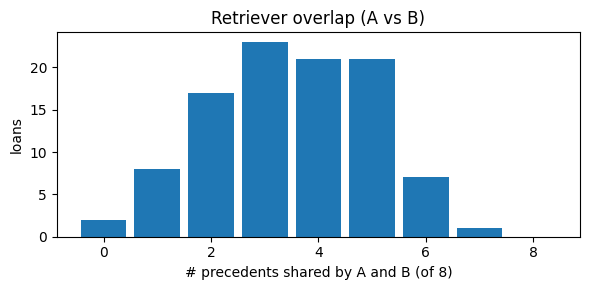

In [6]:
overlaps = np.array([len(a & b) for a, b in zip(A_sets, B_sets)])
jaccard  = np.array([len(a & b) / len(a | b) for a, b in zip(A_sets, B_sets)])
print(f'Precedents shared by A and B (out of {K_PRECEDENTS}): '
      f'mean {overlaps.mean():.2f}, median {np.median(overlaps):.0f}')
print(f'Mean Jaccard(A top-K, B top-K): {jaccard.mean():.2f}')
print(f'Loans where A and B overlap < 50%: {(jaccard < 0.5).mean() * 100:.0f}%')
print('\nRule of thumb: mean Jaccard < ~0.5 => A and B are complementary, '
      'the hybrid is worth running; >> 0.5 => they largely agree, fusion adds little.')
plt.figure(figsize=(6, 3))
plt.hist(overlaps, bins=range(K_PRECEDENTS + 2), align='left', rwidth=0.85)
plt.xlabel(f'# precedents shared by A and B (of {K_PRECEDENTS})'); plt.ylabel('loans')
plt.title('Retriever overlap (A vs B)'); plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05c_retriever_overlap.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Run the hybrid RAG LLM
⚠️ One API call per loan — set `N_TEST` small first.

In [7]:
test_rag, rag_prompt_fn = R.make_rag_prompt_fn(test, blocks)
rag_system_prompt = R.build_rag_system_prompt()

rag = run_llm_experiment(
    test_rag, api_provider=API_PROVIDER, model_name=MODEL_NAME,
    api_keys=API_KEYS, max_workers=MAX_WORKERS, use_cache=not FORCE_RERUN,
    label=f'{MODEL_LABEL} | RAG-C hybrid RRF', include_desc=False,
    with_logprobs=WITH_LOGPROBS, system_prompt=rag_system_prompt,
    user_prompt_fn=rag_prompt_fn, notebook_id=NOTEBOOK_ID,
)
print('Hybrid RAG metrics:', rag['metrics'])

[GPT-5.4 | RAG-C hybrid RRF | no_desc] First call OK (pred=0, prob=0.0). Running 100 loans on 10 key(s) × 40 worker(s)...
[GPT-5.4 | RAG-C hybrid RRF | no_desc] 26/100 done (3s elapsed, ~9s remaining)
[GPT-5.4 | RAG-C hybrid RRF | no_desc] 51/100 done (5s elapsed, ~5s remaining)
[GPT-5.4 | RAG-C hybrid RRF | no_desc] 76/100 done (7s elapsed, ~2s remaining)
[GPT-5.4 | RAG-C hybrid RRF | no_desc] 100/100 done (19s elapsed, ~0s remaining)
[GPT-5.4 | RAG-C hybrid RRF | no_desc] COMPLETE — 100 predictions, 0 parse errors, 100 with logprobs, 19s total

GPT-5.4 | RAG-C hybrid RRF (no_desc) Results (100 samples)
Accuracy: 78.0%
AUC:      0.530  (over 100 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.12      0.22      0.15         9
  Fully Paid       0.92      0.84      0.87        91

    accuracy                           0.78       100
   macro avg       0.52      0.53      0.51       100
weighted avg       0.84      

## 6. Baselines — no-RAG LLM and XGBoost (same validation loans)

In [ ]:
base = run_llm_experiment(
    test, api_provider=API_PROVIDER, model_name=MODEL_NAME,
    api_keys=API_KEYS, max_workers=MAX_WORKERS, use_cache=not FORCE_RERUN,
    label=f'{MODEL_LABEL} | no-RAG', include_desc=False,
    with_logprobs=WITH_LOGPROBS, notebook_id=NOTEBOOK_ID,
)

xgb_probs, xgb_preds = run_ml_on_sample(test)
xgb_metrics = evaluate_predictions(test['loan_status'].values, xgb_preds,
                                   label='XGBoost', probabilities=xgb_probs)

[GPT-5.4 | no-RAG | no_desc] First call OK (pred=0, prob=0.0). Running 100 loans on 10 key(s) × 40 worker(s)...
[GPT-5.4 | no-RAG | no_desc] 26/100 done (3s elapsed, ~8s remaining)
[GPT-5.4 | no-RAG | no_desc] 51/100 done (4s elapsed, ~4s remaining)
[GPT-5.4 | no-RAG | no_desc] 76/100 done (6s elapsed, ~2s remaining)


## 7. Leaderboard + save
Pulls in the Approach A / B rows from `05a_summary.csv` / `05b_summary.csv` if you've run those notebooks, so all five models sit in one table.

In [ ]:
def _row(name, m):
    return {'model': name, **{k: m.get(k) for k in
            ['accuracy', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off', 'auc']}}

rows = [_row('RAG-C (hybrid RRF)', rag['metrics'])]
# Bring in A and B if their summaries exist
for f in ('05a_summary.csv', '05b_summary.csv'):
    p = f'{RESULTS_DIR}/{f}'
    if os.path.exists(p):
        prev = pd.read_csv(p)
        for _, r in prev[prev['model'].str.startswith('RAG-')].iterrows():
            rows.append(r.to_dict())
rows += [_row('LLM no-RAG', base['metrics']), _row('XGBoost', xgb_metrics)]

summary = pd.DataFrame(rows).drop_duplicates(subset='model').reset_index(drop=True)
display(summary)
summary.to_csv(f'{RESULTS_DIR}/05c_summary.csv', index=False)

preds = pd.DataFrame({
    'loan_index': range(len(test)),
    'actual':     test['loan_status'].values,
    'rag_pred':   rag['predictions'],
    'rag_prob':   rag['probabilities'],
    'norag_pred': base['predictions'],
    'xgb_pred':   xgb_preds,
    'xgb_prob':   xgb_probs,
})
preds.to_csv(f'{RESULTS_DIR}/05c_predictions.csv', index=False)
print(f'Saved -> {RESULTS_DIR}/05c_summary.csv  and  05c_predictions.csv')

In [ ]:
ax = summary.set_index('model')[['accuracy', 'f1_charged_off']].plot.bar(rot=20, figsize=(9, 4))
ax.set_title('Approach C (hybrid RRF) vs A, B, and baselines')
ax.set_ylabel('score'); plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05c_comparison.png', dpi=150, bbox_inches='tight'); plt.show()